# Outlier case study (Random Forest)

Identifies MOFs consistently mispredicted across the 9 Random Forest conditions, characterises them structurally, classifies them by descriptor set, and runs per-structure SHAP case studies. Pipeline step 12.

Inputs:
- models/rf/optuna/*.joblib
- data/splits/*
- data/merged/hmof_merged.parquet

Output:
- results/prediction-outlier-analysis/outlier_predictions_rf.parquet
- plots

Environment:
Runs in the core analysis environment (Python 3.11). Key packages: shap, scikit-learn, joblib, seaborn, matplotlib, pandas, numpy.

In [1]:
import sys, os, pathlib, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import shap
warnings.filterwarnings('ignore')

# Project root
for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / '.git').exists():
        ROOT = _p
        break
else:
    ROOT = pathlib.Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from src.data_utils import load_experiment

SPLITS_DIR = ROOT / 'data' / 'splits'
MASTER     = ROOT / 'data' / 'merged' / 'hmof_merged.parquet'
MODELS_RF  = ROOT / 'models' / 'rf' / 'optuna'
SHAP_RF    = ROOT / 'results' / 'rf' / 'shap'
RESULTS    = ROOT / 'results' / 'prediction-outlier-analysis'
RESULTS.mkdir(parents=True, exist_ok=True)

TARGET_IDX  = 2          # co2_mol_kg_0.1bar
FEAT_SETS   = ['geo_all', 'rac_all', 'combined_all']
SPLITS_LIST = ['random', 'topology', 'metal']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print(f'Project root: {ROOT}')
print(f'Models found: {len(list(MODELS_RF.glob("*.joblib")))}')

Project root: /Users/alinapopov/Desktop/04_GitHub/dc-mof-project
Models found: 21


/Users/alinapopov/Desktop/04_GitHub/dc-mof-project/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate per-MOF predictions for all 9 RF conditions

In [2]:
records = []

for split in SPLITS_LIST:
    names = pd.read_parquet(
        SPLITS_DIR / f'split_{split}_test_merged.parquet', columns=['name']
    )['name'].values

    for fs in FEAT_SETS:
        model_path = MODELS_RF / f'{fs}__{split}.joblib'
        if not model_path.exists():
            print(f'  MISSING: {model_path.name}')
            continue

        _, X_test, _, y_test = load_experiment(split, fs)
        model = joblib.load(model_path)

        y_true    = y_test[:, TARGET_IDX]
        y_pred    = model.predict(X_test)
        residual  = y_pred - y_true
        abs_error = np.abs(residual)

        for i, name in enumerate(names):
            records.append({
                'name': name, 'split': split, 'feature_set': fs,
                'y_true': y_true[i], 'y_pred': y_pred[i],
                'residual': residual[i], 'abs_error': abs_error[i],
            })

        print(f'[done] rf/{fs}__{split}  '
              f'RMSE={np.sqrt(np.mean(residual**2)):.4f}  '
              f'n={len(names)}')

preds = pd.DataFrame(records)
preds['condition'] = preds['split'] + '__' + preds['feature_set']
preds.to_parquet(RESULTS / 'outlier_predictions_rf.parquet', index=False)
print(f'\nSaved {len(preds):,} prediction rows covering {preds["name"].nunique():,} unique MOFs')

[done] rf/geo_all__random  RMSE=0.3740  n=11147
[done] rf/rac_all__random  RMSE=0.6095  n=11147
[done] rf/combined_all__random  RMSE=0.3151  n=11147
[done] rf/geo_all__topology  RMSE=0.3244  n=60
[done] rf/rac_all__topology  RMSE=0.5895  n=60
[done] rf/combined_all__topology  RMSE=0.3515  n=60
[done] rf/geo_all__metal  RMSE=0.3800  n=29234
[done] rf/rac_all__metal  RMSE=0.6550  n=29234
[done] rf/combined_all__metal  RMSE=0.3508  n=29234

Saved 121,323 prediction rows covering 37,422 unique MOFs


## Flag outliers and compute persistence scores

Outlier threshold per condition: |residual| > 2 × std(abs_error) for that condition

In [3]:
# Per-condition 2σ thresholds
thresholds = (
    preds.groupby('condition')['abs_error']
    .std()
    .mul(2)
    .rename('threshold')
)
preds = preds.drop(columns=['threshold'], errors='ignore')
preds = preds.join(thresholds, on='condition')
preds['is_outlier'] = preds['abs_error'] > preds['threshold']

print('Outlier rate per condition:')
print(
    preds.groupby('condition')['is_outlier']
    .mean()
    .mul(100)
    .round(1)
    .to_string()
)

Outlier rate per condition:
condition
metal__combined_all       10.0
metal__geo_all            10.5
metal__rac_all             9.0
random__combined_all       8.4
random__geo_all            8.9
random__rac_all            9.1
topology__combined_all    10.0
topology__geo_all         16.7
topology__rac_all         10.0


In [4]:
# Persistence score: fraction of conditions where each MOF is flagged
n_seen      = preds.groupby('name')['condition'].count()
n_outlier   = preds[preds['is_outlier']].groupby('name')['condition'].count()
persistence = (n_outlier / n_seen).fillna(0).sort_values(ascending=False)

print(f'MOFs that are outliers in ALL conditions:    {(persistence == 1.0).sum()}')
print(f'MOFs that are outliers in >50% conditions:  {(persistence > 0.5).sum()}')
print(f'MOFs that are outliers in any condition:    {(persistence > 0).sum()}')
print(f'Total unique MOFs in test sets:             {len(persistence)}')

MOFs that are outliers in ALL conditions:    1092
MOFs that are outliers in >50% conditions:  2956
MOFs that are outliers in any condition:    6756
Total unique MOFs in test sets:             37422


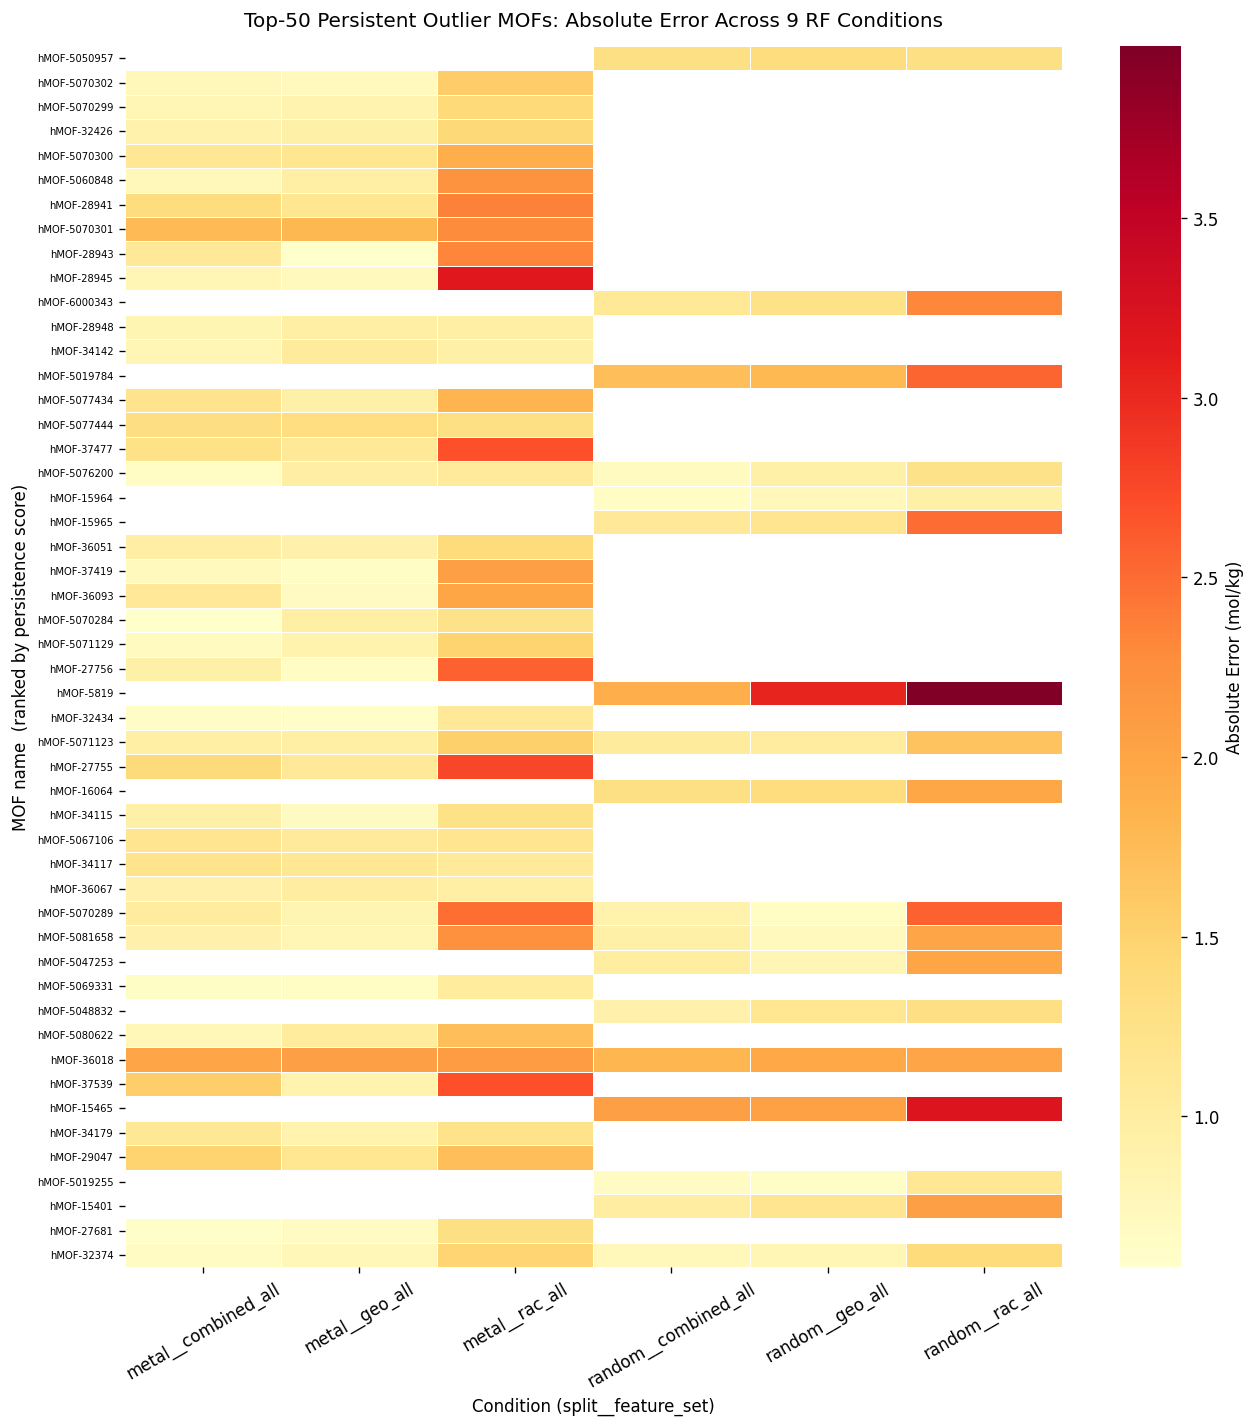

In [5]:
# Heatmap: top-50 persistent MOFs × 9 conditions, colored by abs_error
top50 = persistence.head(50).index

heat_df = (
    preds[preds['name'].isin(top50)]
    .pivot_table(index='name', columns='condition', values='abs_error', aggfunc='mean')
    .loc[top50]
)

fig, ax = plt.subplots(figsize=(11, 12))
sns.heatmap(
    heat_df, ax=ax, cmap='YlOrRd',
    cbar_kws={'label': 'Absolute Error (mol/kg)'},
    linewidths=0.3, linecolor='white'
)
ax.set_title('Top-50 Persistent Outlier MOFs: Absolute Error Across 9 RF Conditions', pad=12)
ax.set_xlabel('Condition (split__feature_set)')
ax.set_ylabel('MOF name  (ranked by persistence score)')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_heatmap_rf.png', bbox_inches='tight')
plt.show()

## Structural characterization of persistent outliers

In [6]:
GEO_COLS = ['pld', 'lcd', 'surface_area_m2g', 'void_fraction', 'density_g_cm3']
meta = pd.read_parquet(
    MASTER,
    columns=['name', 'topology', 'metal_node'] + GEO_COLS
).set_index('name')

persistent_threshold = 0.5
top_names = persistence[persistence >= persistent_threshold].index
meta_out  = meta.loc[meta.index.isin(top_names)]
meta_all  = meta
print(f'Characterizing {len(meta_out)} MOFs with persistence >= {persistent_threshold}')

Characterizing 3027 MOFs with persistence >= 0.5


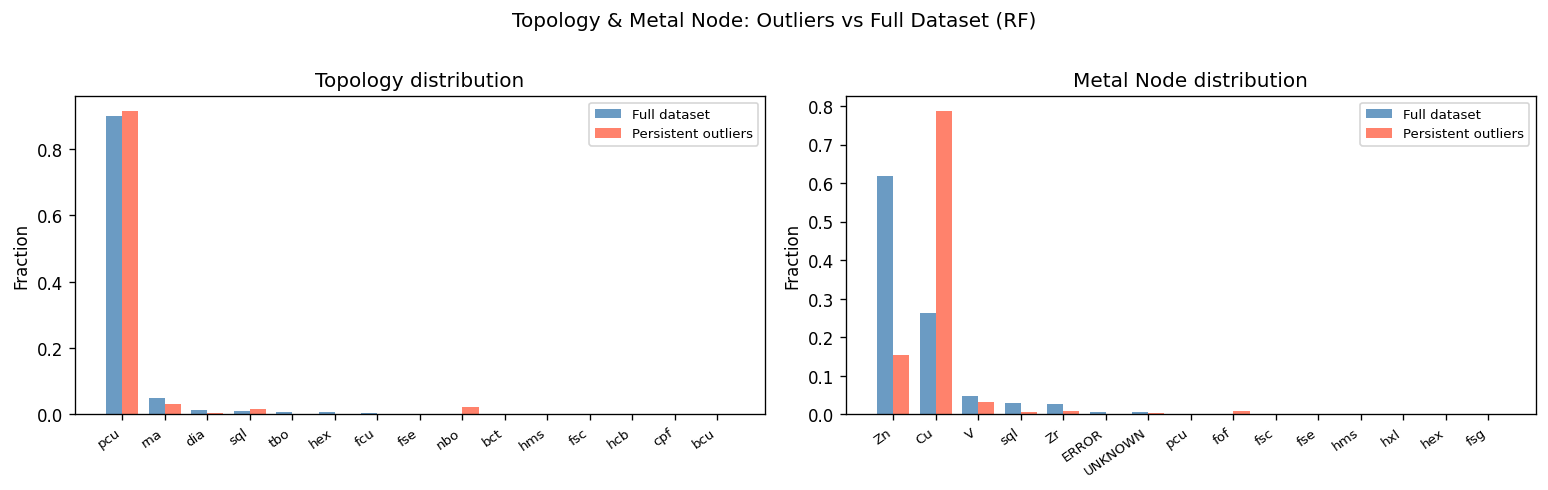

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['topology', 'metal_node'],
    ['Topology', 'Metal Node']
):
    frac_all = meta_all[col].value_counts(normalize=True).head(15)
    frac_out = meta_out[col].value_counts(normalize=True).reindex(frac_all.index, fill_value=0)

    x = np.arange(len(frac_all))
    w = 0.38
    ax.bar(x - w/2, frac_all.values, width=w, label='Full dataset',        color='steelblue', alpha=0.8)
    ax.bar(x + w/2, frac_out.values, width=w, label='Persistent outliers', color='tomato',    alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(frac_all.index, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Fraction')
    ax.set_title(f'{title} distribution')
    ax.legend(fontsize=8)

plt.suptitle('Topology & Metal Node: Outliers vs Full Dataset (RF)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_structure_dist_rf.png', bbox_inches='tight')
plt.show()

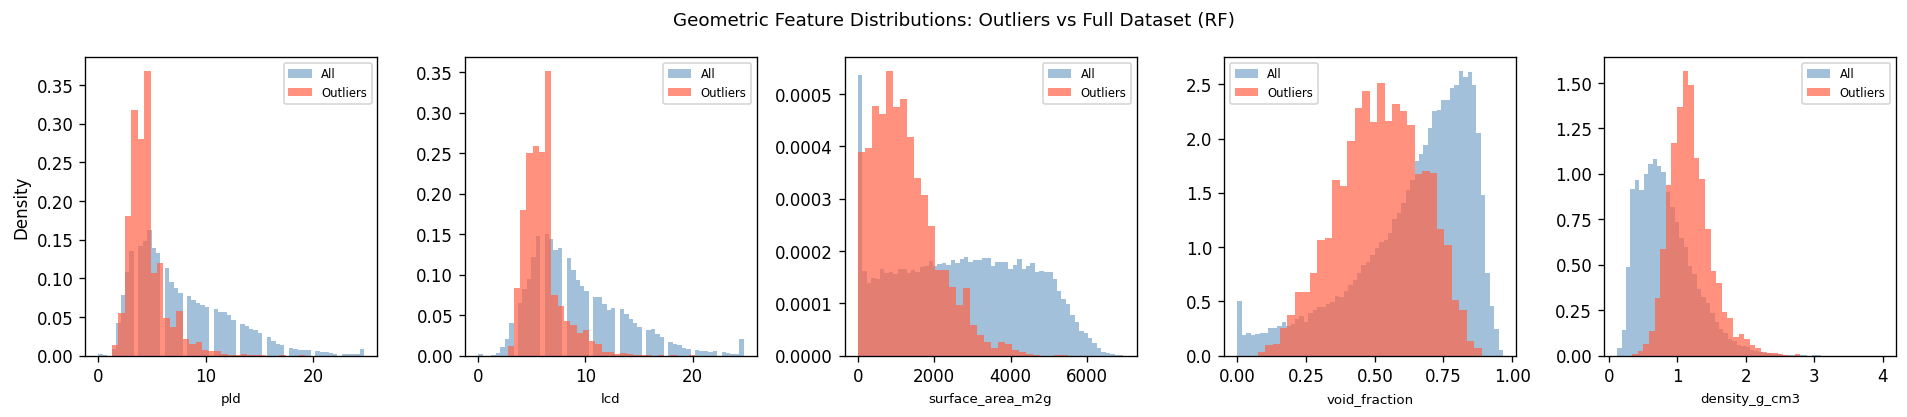

In [8]:
# Geometric feature distributions: outliers vs. full dataset
fig, axes = plt.subplots(1, len(GEO_COLS), figsize=(16, 3.5))

for ax, col in zip(axes, GEO_COLS):
    ax.hist(meta_all[col].dropna(), bins=60, density=True,
            color='steelblue', alpha=0.5, label='All')
    ax.hist(meta_out[col].dropna(), bins=30, density=True,
            color='tomato', alpha=0.7, label='Outliers')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Density' if ax == axes[0] else '')
    ax.legend(fontsize=7)

plt.suptitle('Geometric Feature Distributions: Outliers vs Full Dataset (RF)', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_geo_dist_rf.png', bbox_inches='tight')
plt.show()

## Descriptor-type dissection

Classify each MOF by which feature sets expose it as an outlier:
- **geo_only**: outlier under `geo_all` but NOT `combined_all` → RAC features fix it
- **always**: outlier under all three → model-agnostic failure
- **rac_only**: outlier under `rac_all` but NOT `combined_all`

In [9]:
# For each (MOF, feature_set): is it an outlier in ANY split under that feature set?
outlier_any_split = (
    preds[preds['is_outlier']]
    .groupby(['name', 'feature_set'])
    .size()
    .gt(0)
    .unstack(fill_value=False)
)
for fs in FEAT_SETS:
    if fs not in outlier_any_split.columns:
        outlier_any_split[fs] = False

geo  = outlier_any_split['geo_all']
rac  = outlier_any_split['rac_all']
comb = outlier_any_split['combined_all']

categories = {
    'Geo only\n(RAC fixes it)':  (geo & ~comb).sum(),
    'RAC only\n(geo fixes it)':  (rac & ~comb).sum(),
    'Always outlier\n(all 3)':   (geo & rac & comb).sum(),
    'Combined only':             (~geo & ~rac & comb).sum(),
    'Never outlier':             (~geo & ~rac & ~comb).sum(),
}

print('MOF counts by outlier category:')
for k, v in categories.items():
    print(f'  {k.replace(chr(10), " "):35s}: {v}')

MOF counts by outlier category:
  Geo only (RAC fixes it)            : 1401
  RAC only (geo fixes it)            : 1860
  Always outlier (all 3)             : 1138
  Combined only                      : 808
  Never outlier                      : 0


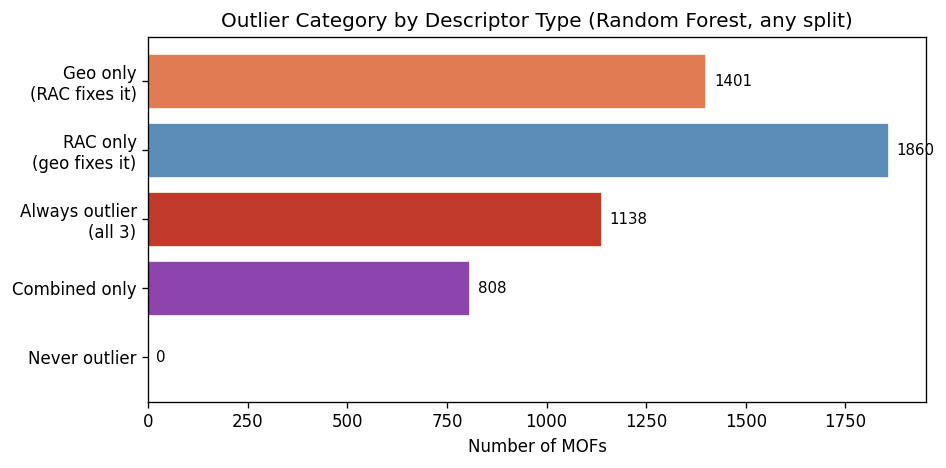

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e07b54', '#5b8db8', '#c0392b', '#8e44ad', '#95a5a6']
labels = list(categories.keys())
values = list(categories.values())

bars = ax.barh(labels, values, color=colors, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of MOFs')
ax.set_title('Outlier Category by Descriptor Type (Random Forest, any split)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_descriptor_categories_rf.png', bbox_inches='tight')
plt.show()

In [11]:
# Identify the 'geo only' MOFs
geo_only_mask = geo & ~comb
geo_only_mofs = outlier_any_split[geo_only_mask].index.tolist()
print(f'"Geo only" outliers (RAC/combined fixes them): {len(geo_only_mofs)}')

# Show their error improvement: geo_all vs combined_all
geo_only_preds = preds[preds['name'].isin(geo_only_mofs)].copy()
error_by_fs = (
    geo_only_preds
    .groupby(['name', 'feature_set'])['abs_error']
    .mean()
    .unstack()
    [FEAT_SETS]
)
error_by_fs['improvement'] = error_by_fs['geo_all'] - error_by_fs['combined_all']
print('\nTop 10 geo-only outliers by error improvement (geo_all -> combined_all):')
print(error_by_fs.sort_values('improvement', ascending=False).head(10).round(4).to_string())

"Geo only" outliers (RAC/combined fixes them): 1401

Top 10 geo-only outliers by error improvement (geo_all -> combined_all):
feature_set   geo_all  rac_all  combined_all  improvement
name                                                     
hMOF-5080034   2.1960   0.5709        0.0747       2.1212
hMOF-5011051   2.3208   2.0631        0.2757       2.0451
hMOF-5082564   1.8769   0.1998        0.0152       1.8618
hMOF-5082333   1.7658   1.1713        0.0621       1.7037
hMOF-5080198   1.7396   0.5424        0.0733       1.6663
hMOF-5062852   1.7621   1.4757        0.1384       1.6238
hMOF-37290     1.6725   1.0415        0.1921       1.4804
hMOF-6001327   1.9008   2.8528        0.4464       1.4544
hMOF-6000600   1.5748   2.0243        0.2324       1.3424
hMOF-5009840   1.4645   1.7218        0.1310       1.3335


## SHAP case study for selected outliers

Pick the top 3 "geo only" outliers (biggest error improvement when adding RAC features)
and show what SHAP says about each.

In [12]:
# Case-study MOF selection — only pick MOFs in the random test set
SPLIT_CS = 'random'

cs_test_names = set(
    pd.read_parquet(
        SPLITS_DIR / f'split_{SPLIT_CS}_test_merged.parquet', columns=['name']
    )['name'].values
)

case_mofs = (
    error_by_fs[error_by_fs.index.isin(cs_test_names)]
    .sort_values('improvement', ascending=False)
    .head(3)
    .index
    .tolist()
)
print(f'MOFs in random test set: {len(cs_test_names)}')
print('Case-study MOFs:', case_mofs)


MOFs in random test set: 11147
Case-study MOFs: ['hMOF-5011051', 'hMOF-5062852', 'hMOF-6001327']


In [14]:
def get_shap_for_mof(mof_name, split, feature_set):
    """
    Compute SHAP values for one MOF using the RF TreeExplainer.

    First tries to reuse the cached .npz SHAP file.
    Falls back to computing fresh via TreeExplainer (fast for RF).
    Returns (shap_values_1d, feature_values_1d, feature_names, expected_value)
    or None if the MOF is not in this split's test set.
    """
    model_path = MODELS_RF / f'{feature_set}__{split}.joblib'
    model = joblib.load(model_path)

    _, X_test, _, _ = load_experiment(split, feature_set)
    names_test = pd.read_parquet(
        SPLITS_DIR / f'split_{split}_test_merged.parquet', columns=['name']
    )['name'].values

    feat_cfg      = json.loads((ROOT / 'data' / 'merged' / 'feature_selection.json').read_text())
    feature_names = feat_cfg['feature_sets'][feature_set]

    mof_idx = np.where(names_test == mof_name)[0]
    if len(mof_idx) == 0:
        return None   # MOF not in this split's test set
    mof_idx = mof_idx[0]

    # Try cached .npz
    npz_path = SHAP_RF / f'{feature_set}__{split}.npz'
    shap_row = None
    if npz_path.exists():
        cached    = np.load(npz_path, allow_pickle=True)
        X_explain = cached['X_explain']
        shap_vals = cached['shap_values']
        exp_val   = float(cached['expected_value'])
        mof_row   = X_test[mof_idx]
        diffs     = np.abs(X_explain - mof_row).sum(axis=1)
        best      = diffs.argmin()
        if diffs[best] < 1e-8:
            shap_row = shap_vals[best]
            x_row    = X_explain[best]

    if shap_row is None:
        # Compute fresh with TreeExplainer (no background dataset needed for RF)
        explainer   = shap.TreeExplainer(model)
        explanation = explainer(X_test[[mof_idx]])
        shap_row    = explanation.values[0]
        x_row       = X_test[mof_idx]
        exp_val     = float(explanation.base_values.mean())

    return shap_row, x_row, feature_names, exp_val

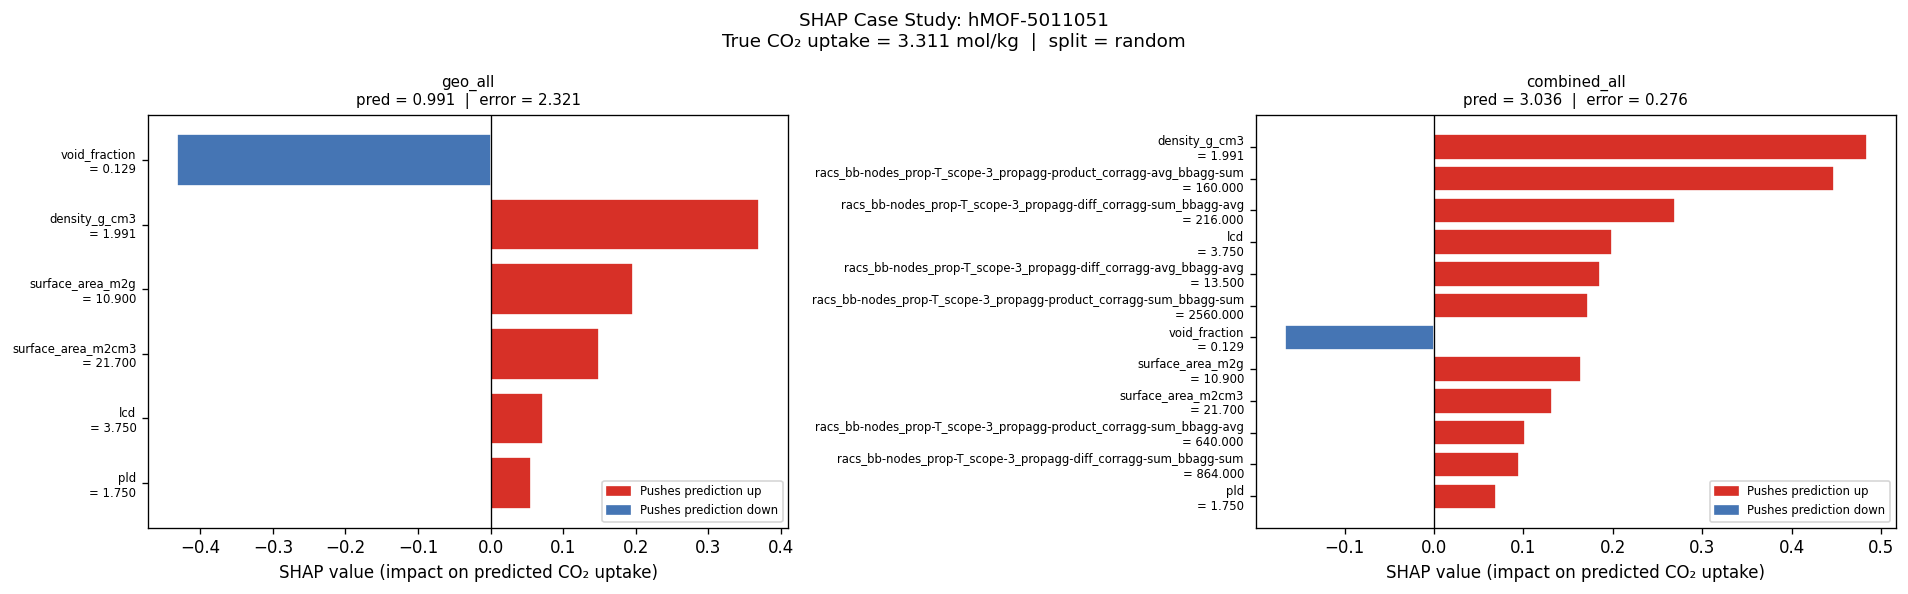

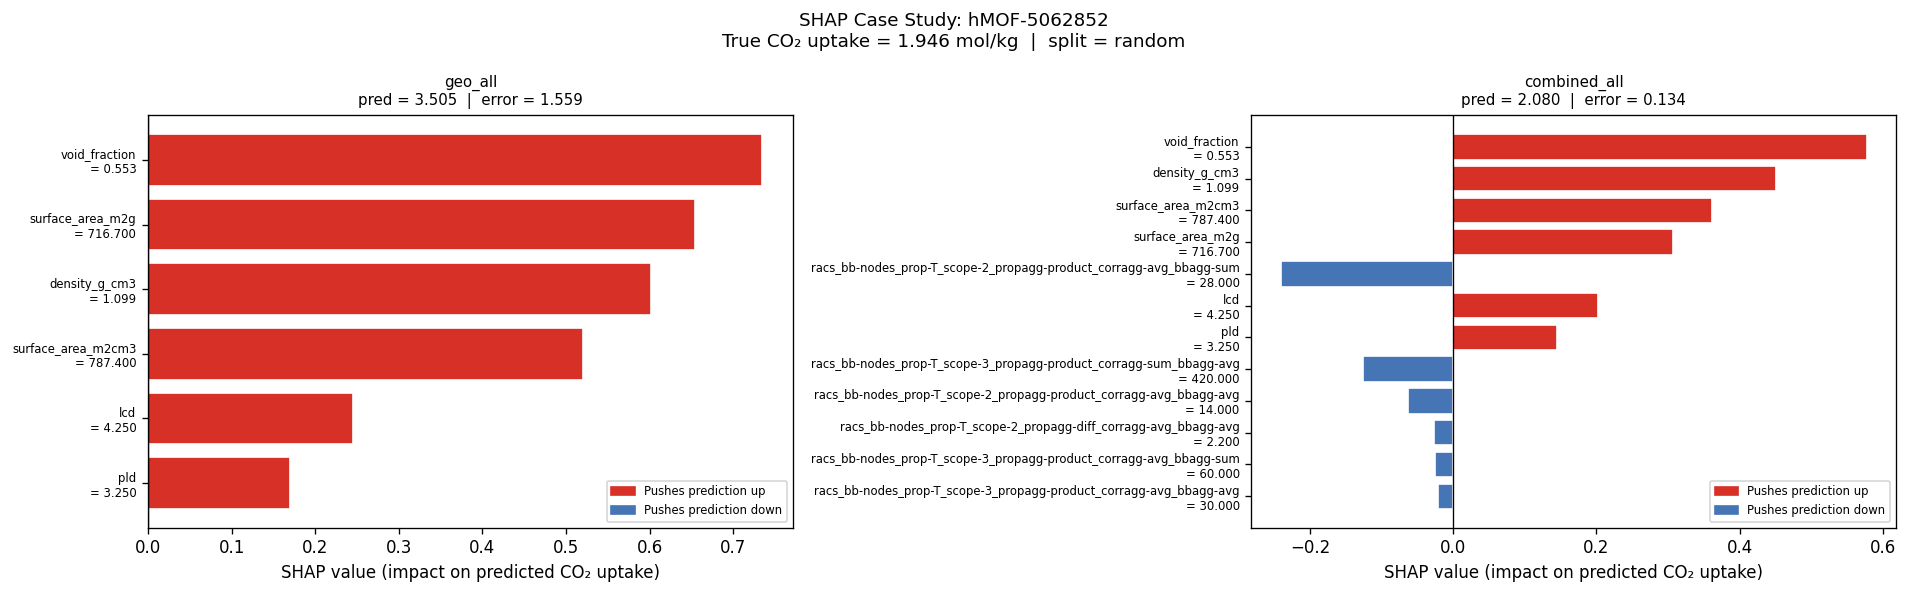

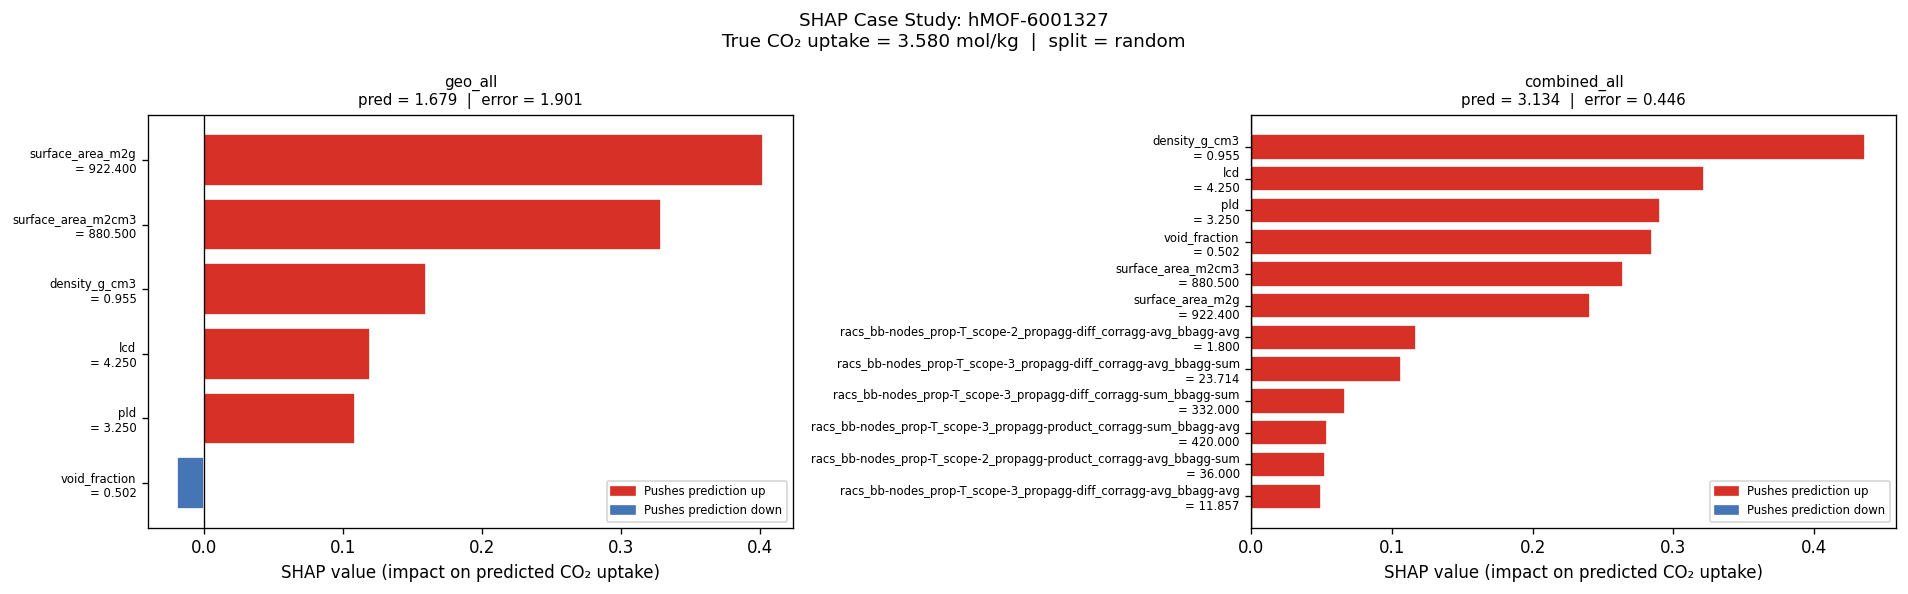

In [15]:
# For each case-study MOF: side-by-side waterfall geo_all vs combined_all (random split)
SPLIT_CS = 'random'

for mof in case_mofs:
    row = preds[(preds['name'] == mof) & (preds['split'] == SPLIT_CS)]
    y_true_val = row['y_true'].iloc[0] if len(row) else float('nan')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f'SHAP Case Study: {mof}\n'
        f'True CO\u2082 uptake = {y_true_val:.3f} mol/kg  |  split = {SPLIT_CS}',
        fontsize=11
    )

    for ax, fs in zip(axes, ['geo_all', 'combined_all']):
        result = get_shap_for_mof(mof, SPLIT_CS, fs)
        if result is None:
            ax.text(0.5, 0.5, f'MOF not in {SPLIT_CS} test set',
                    transform=ax.transAxes, ha='center')
            ax.set_title(fs)
            continue

        sv, xv, fn, ev = result

        mof_row_pred = preds[(preds['name'] == mof) &
                             (preds['split'] == SPLIT_CS) &
                             (preds['feature_set'] == fs)]
        pred_display = mof_row_pred['y_pred'].iloc[0]    if len(mof_row_pred) else ev + sv.sum()
        err_display  = mof_row_pred['abs_error'].iloc[0] if len(mof_row_pred) else abs(pred_display - y_true_val)

        # Top-N features by |SHAP|
        N     = min(12, len(sv))
        order = np.argsort(np.abs(sv))[::-1][:N]
        sv_top = sv[order]
        fn_top = [fn[i] for i in order]
        xv_top = xv[order]

        colors = ['#d73027' if v > 0 else '#4575b4' for v in sv_top]
        y_pos  = np.arange(N)
        ax.barh(y_pos, sv_top, color=colors, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(
            [f'{n}\n= {v:.3f}' for n, v in zip(fn_top, xv_top)],
            fontsize=7
        )
        ax.invert_yaxis()
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('SHAP value (impact on predicted CO\u2082 uptake)')
        ax.set_title(
            f'{fs}\npred = {pred_display:.3f}  |  error = {err_display:.3f}',
            fontsize=9
        )
        red_patch  = mpatches.Patch(color='#d73027', label='Pushes prediction up')
        blue_patch = mpatches.Patch(color='#4575b4', label='Pushes prediction down')
        ax.legend(handles=[red_patch, blue_patch], fontsize=7, loc='lower right')

    plt.tight_layout()
    safe_name = mof.replace('/', '_').replace(' ', '_')
    plt.savefig(RESULTS / f'outlier_shap_{safe_name}_rf.png', bbox_inches='tight')
    plt.show()